**IMPORTING LIBRARIES**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**LOADING DATA**

In [3]:
data=pd.read_csv("online_retail_data.csv")

In [8]:
data.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


In [11]:
data.shape

(1067371, 8)

In [16]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Quantity,1067371.0,9.938898,172.705794,-80995.00,1.00,3.0,10.00,80995.0
Price,1067371.0,4.649388,123.553059,-53594.36,1.25,2.1,4.15,38970.0
Customer ID,824364.0,15324.638504,1697.464450,12346.00,13975.00,15255.0,16797.00,18287.0


In [18]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  str           
 1   StockCode    1067371 non-null  str           
 2   Description  1062989 non-null  str           
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 65.1 MB


**DATA CLEANING**

Convert data type

In [17]:
data['InvoiceDate']=pd.to_datetime(data['InvoiceDate'])

Handle Missing Values

In [21]:
data.isnull().sum()
df_customer=data.dropna(subset=['Customer ID'])

Removing Invalid Values

In [22]:
data=data[data['Quantity']!=0]
data=data[data['Price']>0]

Handling Cancellations

In [23]:
data['IsCancelled'] = data['Invoice'].str.startswith('C')

Separate Sales & Returns

In [ ]:
sales_df=data[data['Quantity']>0]
returns_df=data[data['Quantity']<0]

**FEATURE ENGINEERING**

Revenue

In [25]:
data['Revenue'] = data['Quantity'] * data['Price']
sales_df['Revenue'] = sales_df['Quantity'] * sales_df['Price']

Time Features

In [ ]:
data['Year'] = data['InvoiceDate'].dt.year
data['Month'] = data['InvoiceDate'].dt.month
data['Day'] = data['InvoiceDate'].dt.day

**ORDER-LEVEL DATA**

In [27]:
order_df = sales_df.groupby('Invoice').agg({
    'Quantity': 'sum',
    'Revenue': 'sum',
    'StockCode': 'nunique',
    'InvoiceDate': 'min',
    'Customer ID': 'first'
}).reset_index()
order_df

,Invoice,Quantity,Revenue,StockCode,InvoiceDate,Customer ID
0,489434,166,505.30,8,2009-12-01 07:45:00,13085.0
1,489435,60,145.80,4,2009-12-01 07:46:00,13085.0
2,489436,193,630.33,19,2009-12-01 09:06:00,13078.0
3,489437,145,310.75,23,2009-12-01 09:08:00,15362.0
4,489438,826,2286.24,17,2009-12-01 09:24:00,18102.0
...,...,...,...,...,...,...
40073,581585,278,329.05,21,2011-12-09 12:31:00,15804.0
40074,581586,66,339.20,4,2011-12-09 12:49:00,13113.0
40075,581587,106,267.45,16,2011-12-09 12:50:00,12680.0
40076,A563185,1,11062.06,1,2011-08-12 14:50:00,NaN


**UNIVARIATE ANALYSIS**

Quantity Distribution

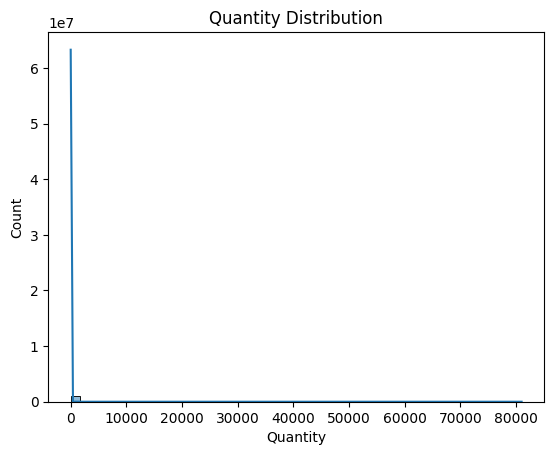

In [46]:
sns.histplot(sales_df['Quantity'], bins=50, kde=True)
plt.title("Quantity Distribution")
plt.show()

Price Distribution

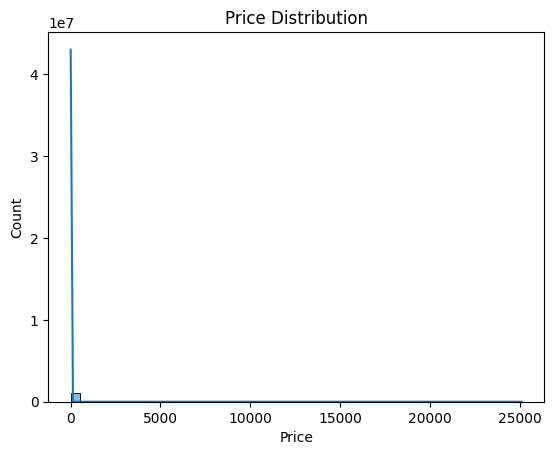

In [47]:
sns.histplot(sales_df['Price'], bins=50, kde=True)
plt.title("Price Distribution")
plt.show()

**CORRELATION ANALYSIS**

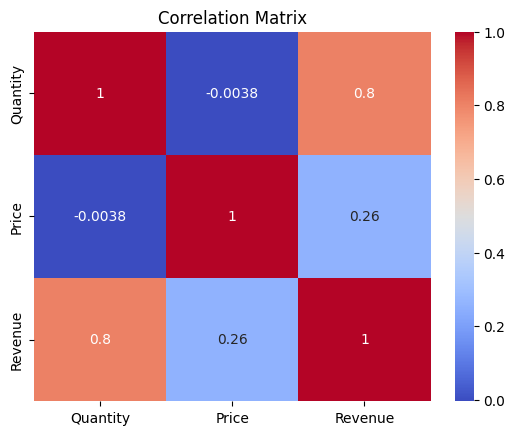

In [55]:
corr = sales_df[['Quantity', 'Price', 'Revenue']].corr()
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

**SALES ANALYSIS**

Total Revenue

In [30]:
total_revenue = sales_df['Revenue'].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 20972968.138


Top Products by Revenue

Top 10 Products by Revenue:
Description
REGENCY CAKESTAND 3 TIER              344563.25
Manual                                341104.90
DOTCOM POSTAGE                        322657.48
WHITE HANGING HEART T-LIGHT HOLDER    266923.55
PAPER CRAFT , LITTLE BIRDIE           168469.60
JUMBO BAG RED RETROSPOT               150935.56
PARTY BUNTING                         149187.05
ASSORTED COLOUR BIRD ORNAMENT         132187.92
POSTAGE                               127597.42
PAPER CHAIN KIT 50'S CHRISTMAS        123141.54
Name: Revenue, dtype: float64


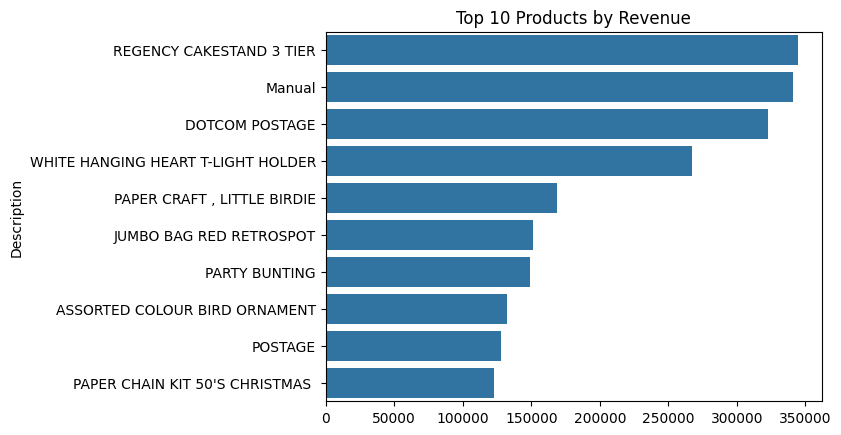

In [48]:
top_products = sales_df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)
print("Top 10 Products by Revenue:")
print(top_products)
sns.barplot(x=top_products.values, y=top_products.index)
plt.title("Top 10 Products by Revenue")
plt.show()

Top Products by Quantity

Top 10 Products by Quantity Sold:
Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     110138
WHITE HANGING HEART T-LIGHT HOLDER     96683
ASSORTED COLOUR BIRD ORNAMENT          81809
PAPER CRAFT , LITTLE BIRDIE            80995
JUMBO BAG RED RETROSPOT                79279
MEDIUM CERAMIC TOP STORAGE JAR         78033
BROCADE RING PURSE                     71430
PACK OF 60 PINK PAISLEY CAKE CASES     56794
60 TEATIME FAIRY CAKE CASES            54716
SMALL POPCORN HOLDER                   49948
Name: Quantity, dtype: int64


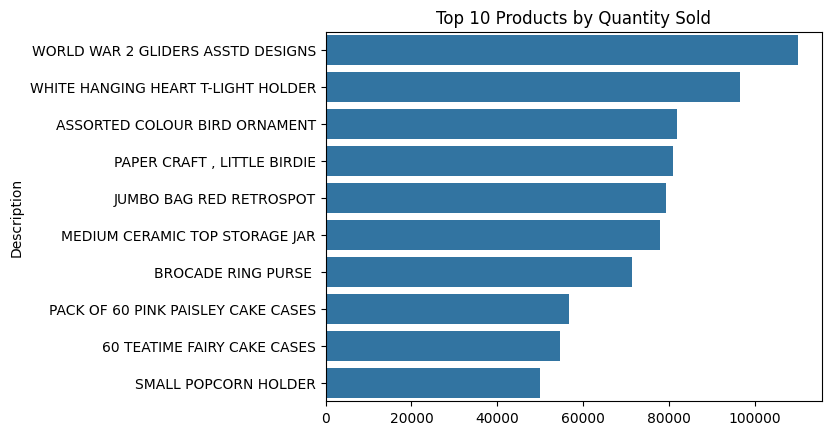

In [49]:
top_quantity = sales_df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
print("Top 10 Products by Quantity Sold:")
print(top_quantity)
sns.barplot(x=top_quantity.values, y=top_quantity.index)
plt.title("Top 10 Products by Quantity Sold")
plt.show()

**CUSTOMER ANALYSIS**

Total Customers

In [33]:
sales_df['Customer ID'].nunique()

5878

Top Customers

Top 10 Customers by Revenue:
Customer ID
18102.0    608821.65
14646.0    528602.52
14156.0    313946.37
14911.0    295972.63
17450.0    246973.09
13694.0    196482.81
17511.0    175603.55
16446.0    168472.50
16684.0    147142.77
12415.0    144458.37
Name: Revenue, dtype: float64


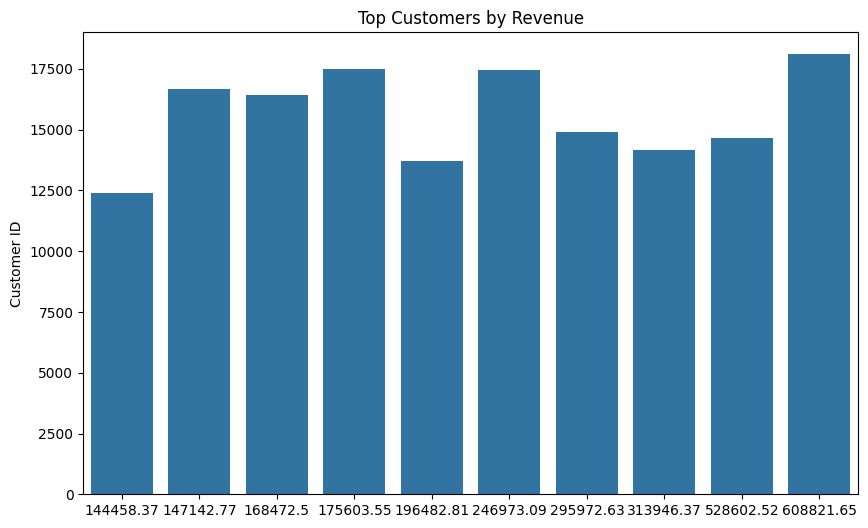

In [51]:
top_customers = sales_df.groupby('Customer ID')['Revenue'].sum().sort_values(ascending=False).head(10)
print("Top 10 Customers by Revenue:")
print(top_customers)
plt.figure(figsize=(10,6))
sns.barplot(x=top_customers.values, y=top_customers.index)
plt.title("Top Customers by Revenue")
plt.show()

Orders per Customer

In [35]:
orders_per_customer = order_df.groupby('Customer ID')['Invoice'].nunique()
print(orders_per_customer.describe())

count    5878.000000
mean        6.289384
std        13.009406
min         1.000000
25%         1.000000
50%         3.000000
75%         7.000000
max       398.000000
Name: Invoice, dtype: float64


**COUNTRY ANALYSIS**

Top Countries by Revenue:
Country
United Kingdom    1.787135e+07
EIRE              6.644318e+05
Netherlands       5.542323e+05
Germany           4.312625e+05
France            3.569446e+05
Australia         1.699681e+05
Spain             1.091785e+05
Switzerland       1.010113e+05
Sweden            9.190372e+04
Denmark           6.986219e+04
Name: Revenue, dtype: float64


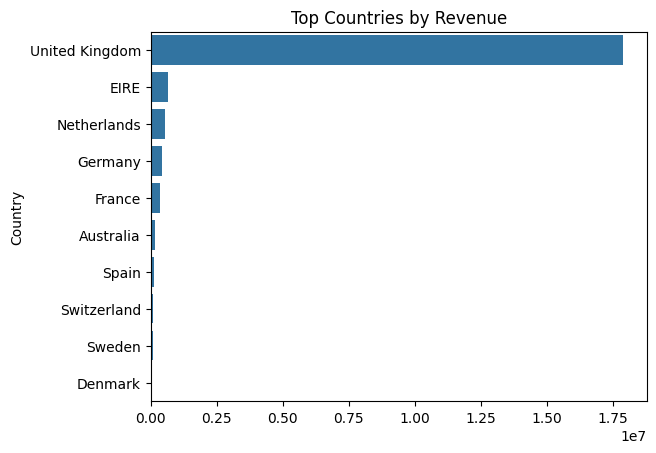

In [52]:
country_sales = sales_df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)
print("Top Countries by Revenue:")
print(country_sales)
sns.barplot(x=country_sales.values, y=country_sales.index)
plt.title("Top Countries by Revenue")
plt.show()

**TIME-BASED ANALYSIS**

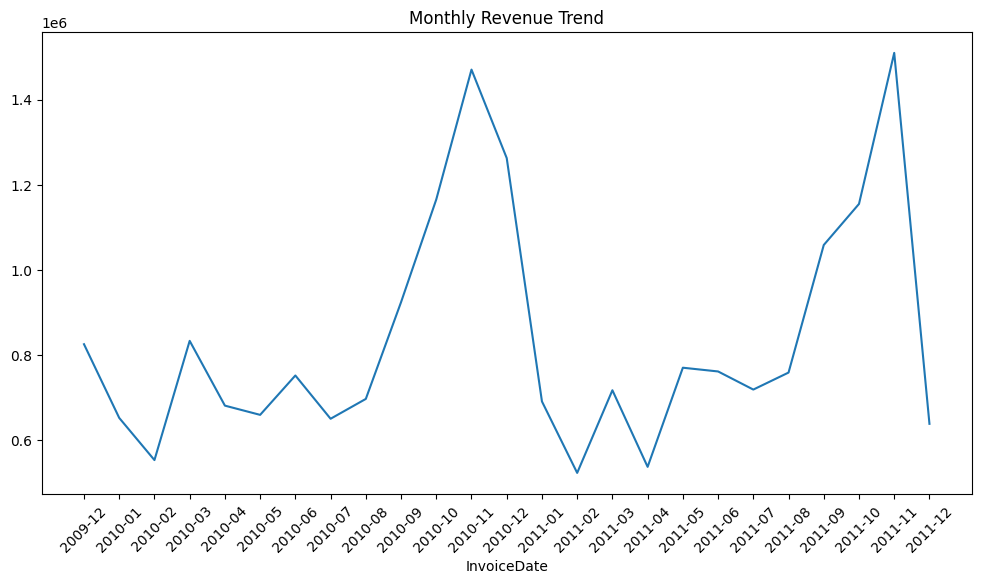

In [ ]:
monthly_sales=sales_df.groupby(sales_df['InvoiceDate'].dt.to_period('M'))['Revenue'].sum()
monthly_sales.index=monthly_sales.index.astype(str)
plt.figure(figsize=(12,6))
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values)
plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend")
plt.show()

**ORDER ANALYSIS**

Average Order Value

In [42]:
AOV = order_df['Revenue'].mean()
print("Average Order Value:", AOV)

Average Order Value: 523.3037611158242


Top Orders

In [43]:
order_df.sort_values('Revenue', ascending=False).head(10)

,Invoice,Quantity,Revenue,StockCode,InvoiceDate,Customer ID
40040,581483,80995,168469.60,1,2011-12-09 09:15:00,16446.0
22233,541431,74215,77183.60,1,2011-01-18 10:01:00,12346.0
37040,574941,14149,52940.94,101,2011-11-07 17:42:00,NaN
37696,576365,13956,50653.91,99,2011-11-14 17:55:00,NaN
18645,533027,13387,49844.99,111,2010-11-15 16:02:00,NaN
17979,531516,12410,45332.97,115,2010-11-08 16:45:00,NaN
1782,493819,25018,44051.60,94,2010-01-07 12:34:00,14156.0
28810,556444,60,38970.00,1,2011-06-10 15:28:00,15098.0
14746,524181,8172,33167.80,13,2010-09-27 16:59:00,17450.0
20724,537659,7378,31770.98,9,2010-12-07 16:43:00,18102.0


**RETURNS ANALYSIS**

Total Returns

In [44]:
returns_df.shape

(19493, 9)

Most Returned Products

In [45]:
returns_products = returns_df.groupby('Description')['Quantity'].sum().sort_values().head(10)
print(returns_products)

Description
PAPER CRAFT , LITTLE BIRDIE           -80995
MEDIUM CERAMIC TOP STORAGE JAR        -74494
ROTATING SILVER ANGELS T-LIGHT HLDR   -18750
SET/6 FRUIT SALAD PAPER CUPS           -7140
SET/6 FRUIT SALAD  PAPER PLATES        -7008
Manual                                 -5451
POP ART PEN CASE & PENS                -5184
BLACK SILVER FLOWER T-LIGHT HOLDER     -5040
MULTICOLOUR SPRING FLOWER MUG          -4996
TEATIME PEN CASE & PENS                -4632
Name: Quantity, dtype: int64
